##### Sylvia Zuniga - CSS Bootcamp Final Project
## How **good** of a word is *penis* as a starting word for New York Time's Wordle?

## And if it is not, what is a **good** starting word?

Now, yes it may seem immature that *penis* is my main word, but we are all adults. I originally chose the word years ago as a joke among friends, but after *feeling* like it was a very good word due to its letter hits I kept using it throughout the years.

But before we get into this, I'll breifly explain what Wordle is and how it works.

According to the Wikipedea: 

"Wordle is a web-based word game... In the game, players have six attempts to guess a five-letter word, receiving feedback through colored tiles that indicate correct letters and their placement. A single puzzle is released daily, with all players attempting to solve the same word."

I had not done the Wordle myself in 2 years and then, on a whim, decided to go to Wordle and use the word I've used so long ago. The following occured.

![Extreme Accuracy Penis](images/2026-08-10.png)


I have never had this happen before, and it sparked a question: **is penis a good starting word for Wordle?**

With this one sample, it does seem like penis is an amazing starting word! However, we can't just base our conclusion on one piece of data. So I attempted to play Wordle almost everyday (I missed a few days unfortunately) for **20** days and out of those days, **19** days the Wordle word shared at least *one* letter with penis. 

![Screenshot of All Data Personally Collected](images/20dayData.png)


*Note: one of the screenshots was corrupted (2026-8-24) but the word was RUNNY, which shares one letter with our target word*

Let's fully calculate the accuracy including taking into account the accuracy of the letter placement when using the word penis.
Let's fully calculate the accuracy when using the word penis, accounting for the letter positions as well.

In [1]:
# import first 
import numpy as np
import pandas as pd
from scipy import stats
from collections import Counter


# ML Imports
# Running the regression:
from statsmodels.formula.api import ols
from statsmodels.formula.api import logit
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Plotting things:
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx


In [2]:
# make a DataFrame that takes the target word (column 1) and checks if it shares any letters with penis (1 or 0) and if it is in the right spot (1 or 0)

# list of words fromt the 20 days
words = ['snipe','fence','wimpy','crash','geode','loose','aspic','tribe','strip','grill','murky','trace','prawn','olden','runny','click','capon','uncut','intel','mound']
# target word
target_word = 'penis'
target_letters = list(target_word)

# using a dictionary so we can use it for larger data sets in the future (we will see this later in the notebook)
data = {'word': words}

for idx, letter in enumerate(target_letters):
    # checks if the word in the word column contains the letters from penis
    data[f'contains_{letter.lower()}'] = [1 if letter in word else 0 for word in words]
    
    # checks if they share position
    data[f'position_{letter.lower()}'] = [
        1 if len(word) > idx and word[idx] == letter else 0 
        for word in words
    ]

# create the data frame
datsmall = pd.DataFrame(data)
datsmall


,word,contains_p,position_p,contains_e,position_e,contains_n,position_n,contains_i,position_i,contains_s,position_s
0,snipe,1,0,1,0,1,0,1,0,1,0
1,fence,0,0,1,1,1,1,0,0,0,0
2,wimpy,1,0,0,0,0,0,1,0,0,0
3,crash,0,0,0,0,0,0,0,0,1,0
4,geode,0,0,1,1,0,0,0,0,0,0
5,loose,0,0,1,0,0,0,0,0,1,0
6,aspic,1,0,0,0,0,0,1,1,1,0
7,tribe,0,0,1,0,0,0,1,0,0,0
8,strip,1,0,0,0,0,0,1,1,1,0
9,grill,0,0,0,0,0,0,1,0,0,0


In [3]:
datsmall.describe()

,contains_p,position_p,contains_e,position_e,contains_n,position_n,contains_i,position_i,contains_s,position_s
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0
mean,0.300000,0.050000,0.400000,0.100000,0.450000,0.100000,0.400000,0.100000,0.250000,0.0
std,0.470162,0.223607,0.502625,0.307794,0.510418,0.307794,0.502625,0.307794,0.444262,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.250000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [4]:
# find the sum of the binaries of each column 
print("Sum of Binary's:")
datsmall.select_dtypes(include=['int', 'float']).sum()

Sum of Binary's:


contains_p    6
position_p    1
contains_e    8
position_e    2
contains_n    9
position_n    2
contains_i    8
position_i    2
contains_s    5
position_s    0
dtype: int64

Based on the findings above, the most commonly shared letter for the 20 days was the letter *n* with 9 counts. *n* was also one out of the three letters (*e* & *i*) with the most correct positioning. However, this still doesn't fully tell us how accurate, nor how *good*, penis is as a starting word. We continue.

Let's look at the accuracy of each letter by postion and then look at the accuracy of the word PENIS for both presence and position.

In [5]:
# accuracy for each letter position
letter_accuracy = {}


for i, letter in enumerate(target_word):
    # takes the sum of the position columns
    correct_positions = datsmall[f'position_{letter}'].sum()
    # calculates the accuracy of each letter
    letter_accuracy[letter] = (correct_positions / len(datsmall)) * 100

print("Per-letter position accuracy:")
for letter, acc in letter_accuracy.items():
    print(f" '{letter}': {acc:.1f}%")

Per-letter position accuracy:
 'p': 5.0%
 'e': 10.0%
 'n': 10.0%
 'i': 10.0%
 's': 0.0%


In [6]:
total_positions = len(datsmall) * len(target_word)

# overall accuracy the presence of target word
total_presence_matches = datsmall[[f'contains_{letter}' for letter in target_word]].sum().sum()
overall_presence_accuracy = (total_presence_matches / total_positions) * 100

# overall accuracy of position of target word
total_position_matches = datsmall[[f'position_{letter}' for letter in target_word]].sum().sum()
overall_position_accuracy = (total_position_matches / total_positions) * 100


print(f"Overall Presence Accuracy: {overall_presence_accuracy:.1f}%")
print(f"Overall Position Accuracy: {overall_position_accuracy:.1f}%")

Overall Presence Accuracy: 36.0%
Overall Position Accuracy: 7.0%


Based on the calculations above, even though the target word shared at least one letter with 95% of the words in 20 days, the overall accuracy is very low since most words only share one or two letters with it. 

### Defining the Goal
This is still a very small amount of data, so let's look at every possible Wordle word (five letter words), and truly see how good PENIS is as a starting word. The goal is not for the starting word to be the BEST. 

We define BEST: a starting word that gets the target word on the first try. 

However, that starting word cannot be the best again the next day since Wordle changes the word everyday. Therefore, instead of looking for the BEST starting word, we are seeing if the choosen starting word is  a *good* starting word.

We define a good starting word: a word that shares one or more letters (either green or yellow) with the target word. The word remains good if it stays consistent, as in you can use the word for the next day's Wordle and it still shares letters with the target word.

We can thank Sean Patlan for taking care of this task. If you'd like to see his process it is on [GitHub](https://github.com/seanpatlan/wordle-words/blob/main/word-bank.csv)!
Sean made two CSV files: 
- **valid-words.csv**: a list of all words that Wordle considers a valid guess (12,972 words)
- **word-bank.csv**: the list of words that Wordle selects the daily word from (2,315 words)

We will use this data to explore the likeliness that PENIS will share letters with the word of the day. 

Let's look at the data.

In [7]:
# read csv
wordle = pd.read_csv('word-bank.csv')
wordle.head(10)

,word
0,aback
1,abase
2,abate
3,abbey
4,abbot
5,abhor
6,abide
7,abled
8,abode
9,abort


In [8]:
p_answers = pd.read_csv('valid-words.csv')
p_answers.head(10)

,word
0,aahed
1,aalii
2,aargh
3,aarti
4,abaca
5,abaci
6,aback
7,abacs
8,abaft
9,abaka


In [9]:
print(f"# of words in used as Wordle answers: {wordle.shape[0]}")
print(f"# of words in used as possible guesses: {p_answers.shape[0]}")

# of words in used as Wordle answers: 2315
# of words in used as possible guesses: 12972


The [wordle] data will be the possible Wordle answers while [p_answers] will be the possible valid guesses users will give. We will focus at looking at the accuracy of the word PENIS with [wordle] first.

We will use the same code I made for my "20 Day Data" but apply it to [wordle].

In [10]:
words = wordle['word']
# target word
target_word = 'penis'
target_letters = list(target_word)

# using a dictionary so we can use it for larger data sets in the future (we will see this later in the notebook)
data = {'word': words}

for idx, letter in enumerate(target_letters):
    # checks if the word in the word column contains the letters from penis
    data[f'contains_{letter.lower()}'] = [1 if letter in word else 0 for word in words]
    
    # checks if they share position
    data[f'position_{letter.lower()}'] = [
        1 if len(word) > idx and word[idx] == letter else 0 
        for word in words
    ]

# create the data frame
dat = pd.DataFrame(data)
dat

,word,contains_p,position_p,contains_e,position_e,contains_n,position_n,contains_i,position_i,contains_s,position_s
0,aback,0,0,0,0,0,0,0,0,0,0
1,abase,0,0,1,0,0,0,0,0,1,0
2,abate,0,0,1,0,0,0,0,0,0,0
3,abbey,0,0,1,0,0,0,0,0,0,0
4,abbot,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2310,young,0,0,0,0,1,0,0,0,0,0
2311,youth,0,0,0,0,0,0,0,0,0,0
2312,zebra,0,0,1,1,0,0,0,0,0,0
2313,zesty,0,0,1,1,0,0,0,0,1,0


Now let's look at the accuracy once more.

In [11]:
datsmall.describe()

,contains_p,position_p,contains_e,position_e,contains_n,position_n,contains_i,position_i,contains_s,position_s
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0
mean,0.300000,0.050000,0.400000,0.100000,0.450000,0.100000,0.400000,0.100000,0.250000,0.0
std,0.470162,0.223607,0.502625,0.307794,0.510418,0.307794,0.502625,0.307794,0.444262,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.250000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [12]:
# column sum
print("Sum of Binary's:")
dat.select_dtypes(include=['int', 'float']).sum()

Sum of Binary's:


contains_p     346
position_p     142
contains_e    1055
position_e     242
contains_n     550
position_n     139
contains_i     647
position_i     158
contains_s     617
position_s      36
dtype: int64

In [13]:
# accuracy for each letter position
letter_accuracy = {}


for i, letter in enumerate(target_word):
    correct_positions = dat[f'position_{letter}'].sum()
    letter_accuracy[letter] = (correct_positions / len(dat)) * 100

print("Per-letter position accuracy:")
for letter, acc in letter_accuracy.items():
    print(f" '{letter}': {acc:.1f}%")

Per-letter position accuracy:
 'p': 6.1%
 'e': 10.5%
 'n': 6.0%
 'i': 6.8%
 's': 1.6%


In [14]:
total_positions = len(dat) * len(target_word)

# overall accuracy the presence of target word
total_presence_matches = dat[[f'contains_{letter}' for letter in target_word]].sum().sum()
overall_presence_accuracy = (total_presence_matches / total_positions) * 100

# overall accuracy of position of target word
total_position_matches = dat[[f'position_{letter}' for letter in target_word]].sum().sum()
overall_position_accuracy = (total_position_matches / total_positions) * 100


print(f"Overall Presence Accuracy: {overall_presence_accuracy:.1f}%")
print(f"Overall Position Accuracy: {overall_position_accuracy:.1f}%")

Overall Presence Accuracy: 27.8%
Overall Position Accuracy: 6.2%


When looking at the possible answers, the letter "e" is more likely to share the same position as PENIS. However, the overall accuracy is not great and below 0.

##### So what does this mean?
It likely means that PENIS is not a *good* starting Wordle word when looking at all the possible Wordle answers.

### So which word would be GOOD?
To find this out we will use Sean's csv word data to make a network graph. 

To make this network graph, we will need to add more columns to the [p_answers] data set that will count, out of the whole alphabet, which letters are present and how many are present in order to calculate distance.

For example, let's say word 1 ($W_1$) is AUDIO and word 2 ($W_2$) is RODEO. 
They would look like such below:
| word | D | O |
|---|---:|---:|
| audio | 1 | 1 |
| rodeo | 1 | 2|

Then we would calulate the distance between $W_1$ and $W_2$ connections per letter as: 
$$\text{distance}(W_1, W_2) = \frac{\sum_{l \in \text{alphabet}} |\text{count}_{W_1}(l) - \text{count}_{W_2}(l)|}{10}$$
where $count_w(l)$ is the number of times letter $l$ appears in word $W$.

It is divided by 10 rather than 5 because it is two 5 letter words.

So for AUDIO and RODEO, since they don't share 6 letters (A,U,I,E,R, and one O) the calculation would be:
$$\frac{|6|}{10} = 0.6$$

The greater the distance the less they the two words share letters.

Let's start by making the data look like this like the table above.

In [15]:
words = p_answers['word']

alphabet = 'abcdefghijklmnopqrstuvwxyz'
target_letters = list(alphabet)

data = {'word': words}

# count how many times it appears
for letter in alphabet:
    data[f'count_{letter}'] = [word.lower().count(letter) for word in words]


# create the data frame
p_answers = pd.DataFrame(data)
p_answers.head()

,word,count_a,count_b,count_c,count_d,count_e,count_f,count_g,count_h,count_i,...,count_q,count_r,count_s,count_t,count_u,count_v,count_w,count_x,count_y,count_z
0,aahed,2,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,aalii,2,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
2,aargh,2,0,0,0,0,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
3,aarti,2,0,0,0,0,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
4,abaca,3,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Let's do the same thing with [wordle].

In [16]:
words = wordle['word']

target_letters = list(alphabet)

data = {'word': words}

# count how many times it appears
for letter in alphabet:
    data[f'count_{letter}'] = [word.lower().count(letter) for word in words]


# create the data frame
wordle = pd.DataFrame(data)
wordle.head()

,word,count_a,count_b,count_c,count_d,count_e,count_f,count_g,count_h,count_i,...,count_q,count_r,count_s,count_t,count_u,count_v,count_w,count_x,count_y,count_z
0,aback,2,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,abase,2,1,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,abate,2,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,abbey,1,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,abbot,1,2,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


We want to make a network graph where the distance between nodes is determined by how many letters the words share. 

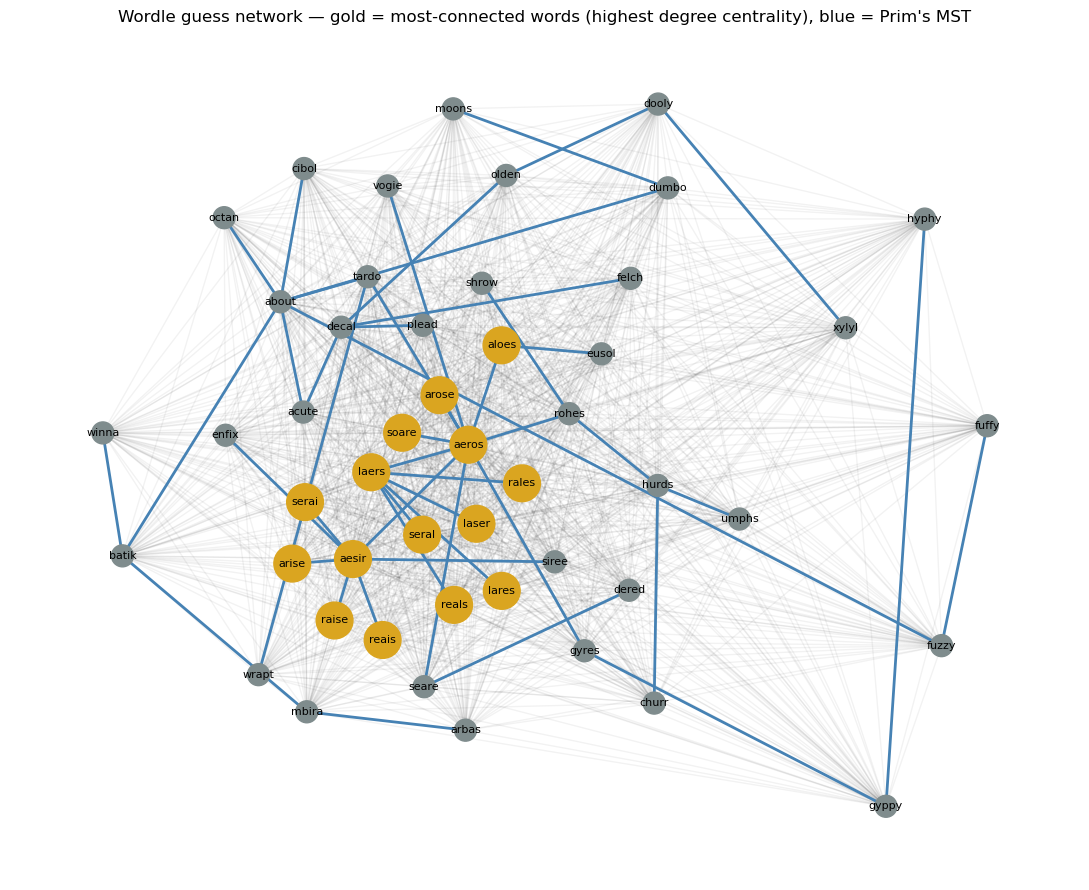

In [17]:
alphabet = 'abcdefghijklmnopqrstuvwxyz'

def degree_centrality_fast(count_df, alphabet=alphabet):
    """Weighted degree centrality for every word in count_df.

    centrality[i] = sum over all other words j of (1 - distance(i, j))
    i.e. how much total letter-overlap word i has with the rest of the list.
    Uses a sort + prefix-sum trick per letter column so it runs in
    O(26 * n log n) instead of the O(n^2) a brute-force pairwise loop would need.
    """

    # pull out the plain word strings, and count how many words we have (n)
    words = count_df['word'].values
    n = len(words)

    # grab just the 26 count (count_a...count_z) columns as a single n x 26 numeric matrix
    # (int64 so the arithmetic below can't silently overflow)
    C = count_df[[f'count_{l}' for l in alphabet]].values.astype(np.int64)

    # this will hold, for every word i, the TOTAL distance from word i to every other word
    # (summed across all 26 letters) -- we build it up one letter column at a time
    dist_sum = np.zeros(n, dtype=np.float64)


    for j in range(len(alphabet)):
        col = C[:, j] # this letter's count for every word, e.g. how many "e"s each word has

        # sort this column's values so we can use prefix sums to answer
        # "sum of |value - x| for every value" without a nested loop
        order = np.argsort(col, kind='mergesort')
        sorted_col = col[order]

        # running total of the sorted values: prefix[k] = sum of the k smallest values
        prefix = np.concatenate(([0], np.cumsum(sorted_col)))
        total = prefix[-1]

        # for each word's own count, find where it would sit in the sorted list (its rank)
        ranks = np.searchsorted(sorted_col, col, side='left')

        # everything with a smaller-or-equal count than this word (the "left" side)
        left_sum, left_count = prefix[ranks], ranks
        # everything with a larger count than this word (the "right" side)
        right_sum, right_count = total - left_sum, n - left_count

        # sum_j |col_i - col_j| for every word i, all at once:
        #   for words with a smaller count: (my count - their count) added up  -> col*left_count - left_sum
        #   for words with a larger count:  (their count - my count) added up  -> right_sum - col*right_count
        # adding both halves gives the total absolute difference for this one letter,
        # and we add it onto the running total across all 26 letters
        dist_sum += col * left_count - left_sum + right_sum - col * right_count

    # normalize: max possible difference between two 5-letter words is 10 (5 letters + 5 letters),
    # so dividing by 10 keeps distance in the 0 (identical) to 1 (no shared letters) range
    avg_distance = (dist_sum / (n - 1)) / 10.0

    # centrality = total similarity to every other word = "how connected" this word is.
    # (n-1) is the max possible score (perfectly similar to everyone else); we subtract off
    # the actual total distance (scaled to 0-1 per comparison) to get total similarity instead
    centrality = (n - 1) - dist_sum / 10.0
    return pd.DataFrame({'word': words, 'avg_distance': avg_distance, 'centrality': centrality})


def word_distance(w1, w2, alphabet=alphabet):
    # brute-force version for just TWO words (fine for a small demo graph, not for 12,972 words)
    # build each word's 26-letter count vector...
    c1 = np.array([w1.count(l) for l in alphabet])
    c2 = np.array([w2.count(l) for l in alphabet])
    # sum the absolute difference across all 26 letters and normalize by 10, same as above
    return np.abs(c1 - c2).sum() / 10.0


# rank every word by centrality (most connected = most letter-overlap with the whole list) ---
centrality_df = degree_centrality_fast(p_answers).sort_values('centrality', ascending=False).reset_index(drop=True)
centrality_df['rank'] = centrality_df.index + 1 # rank 1 = most central/most connected word

# build a small demo graph + Prim's MST, using only the data itself 
# we can't plot all 12,972 words readably
top_words = centrality_df.head(15)['word'].tolist() # top 15 most connected words
bottom_words = centrality_df.tail(5)['word'].tolist() # 5 least connected words 

np.random.seed(42) # fixes the randomness so the sample (and the resulting plot) is reproducible
sample_words = list(np.random.choice(centrality_df['word'], 30, replace=False)) # 30 random words from the middle of the list

# combine all three groups into one node list, removing any duplicates, and sort for consistency
node_words = sorted(set(top_words + bottom_words + sample_words))

# building graph nodes for each word
G = nx.Graph()
G.add_nodes_from(node_words)

# connect every pair of nodes with an edge weighted by their letter distance
# (this is a "complete" graph -- every word is connected to every other word in our sample)
for i in range(len(node_words)):
    for j in range(i + 1, len(node_words)):
        d = word_distance(node_words[i], node_words[j])
        # store both distance (for MST, where lower = better/cheaper) and similarity (for layout, where higher = pull closer)
        G.add_edge(node_words[i], node_words[j], distance=d, similarity=1 - d)

# Prim's algorithm: find the minimum spanning tree -- the cheapest possible set of edges
# (by total letter-distance) that still connects every node in the graph
mst = nx.minimum_spanning_tree(G, weight='distance', algorithm='prim')

# plot
# spring_layout uses the edge weights to decide positions: words with high "similarity"
# get pulled closer together, so tightly-related words naturally cluster
pos = nx.spring_layout(G, weight='similarity', seed=7, k=0.6)

node_color = ['goldenrod' if w in top_words else '#7f8c8d' for w in G.nodes()] # gold + bigger for the top-15 most-connected words, grey smaller for everything else
node_size = [700 if w in top_words else 250 for w in G.nodes()]

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(G, pos, alpha=0.05, ax=ax)
nx.draw_networkx_edges(mst, pos, edge_color='steelblue', width=2, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Wordle guess network — gold = most-connected words (highest degree centrality), blue = Prim's MST")
ax.axis('off')
plt.tight_layout()
plt.show()

In [18]:
# find our top word(s) by centrality 
top_score = centrality_df['centrality'].max()
most_central_words = centrality_df[centrality_df['centrality'] == top_score]['word'].tolist()
print(f"Most central word(s): {most_central_words} (centrality score: {top_score:.1f})")

Most central word(s): ['aeros', 'arose', 'soare'] (centrality score: 4957.2)


Based on the network graph and calculations, the top good starting words for Wordle are AEROS, AROSE, and SOARE based on centrality.
I find this surprising since I didn't feel that O or R was that common of a letter.

HOWEVER: This is a network graph based on valid answers that a user can input to guess the word of the day on Wordle. This has many uncommon words (and wack words frankly) that a user wouldn't really think of using, nor would they be used as Wordle answers. 

So now let's look at the most central word using the [wordle] data frame I made using Seans word-bank.csv.
I cross check the possible user input words with the [wordle] data set. 

In [19]:
def cross_set_centrality(query_df, target_df, alphabet=alphabet):
    """For every word in query_df, total letter-overlap with every word in target_df.
    query_df = the candidate pool (e.g. all valid guesses)
    target_df = the set you actually care about matching (e.g. real answers)
    """
    # plain word strings from each dataframe
    query_words = query_df['word'].values
    target_words = target_df['word'].values

    # how many words are in each set -- these are DIFFERENT numbers now
    # (nq = 12,972 guesses, nt = 2,315 real answers), unlike degree_centrality_fast
    # where it was the same dataframe compared to itself
    nq, nt = len(query_words), len(target_words)

    # pull out the 26 letter-count columns as plain numeric matrices, one per DataFrame
    Cq = query_df[[f'count_{l}' for l in alphabet]].values.astype(np.int64)
    Ct = target_df[[f'count_{l}' for l in alphabet]].values.astype(np.int64)

    # will hold, for every QUERY word, its total distance to every TARGET word
    dist_sum = np.zeros(nq, dtype=np.float64)


    for j in range(len(alphabet)):
        # sort the TARGET set's counts for this letter
        # (not the query set. we're always measuring query words AGAINST the answer set)
        tcol = Ct[:, j]
        order = np.argsort(tcol, kind='mergesort')
        sorted_t = tcol[order]
        prefix = np.concatenate(([0], np.cumsum(sorted_t)))
        total = prefix[-1] # sum of every target word's count for this letter

        # for each QUERY word's count, find where it would land among the sorted TARGET counts
        qcol = Cq[:, j]
        ranks = np.searchsorted(sorted_t, qcol, side='left')

        # target words with a count <= this query word's count ("left" side)
        left_sum, left_count = prefix[ranks], ranks
        # target words with a count > this query word's count ("right" side)
        right_sum, right_count = total - left_sum, nt - left_count

        # same absolute-difference trick as before, but now every query word is being
        # measured against the full target set instead of against its own dataframe
        dist_sum += qcol * left_count - left_sum + right_sum - qcol * right_count

    # normalize by (max distance per comparison=10), so avg_distance stays on
    # the familiar 0-1 scale, averaged over all nt comparisons
    avg_distance = (dist_sum / nt) / 10.0

    # centrality_to_answers = total similarity to the target set specifically.
    # max possible score is nt (perfectly similar to every single answer),
    # so subtracting the actual total distance gives total similarity instead
    centrality = nt - dist_sum / 10.0   
    return pd.DataFrame({'word': query_words, 'avg_distance_to_answers': avg_distance,
                          'centrality_to_answers': centrality})

# every valid guess, scored by overlap with the real answer set only
guess_vs_answers = cross_set_centrality(p_answers, wordle).sort_values('centrality_to_answers', ascending=False).reset_index(drop=True)
print(guess_vs_answers.head(15))

     word  avg_distance_to_answers  centrality_to_answers
0   orate                 0.642160                  828.4
1   oater                 0.642160                  828.4
2   roate                 0.642160                  828.4
3   realo                 0.643801                  824.6
4   alter                 0.644320                  823.4
5   artel                 0.644320                  823.4
6   taler                 0.644320                  823.4
7   later                 0.644320                  823.4
8   ratel                 0.644320                  823.4
9   alert                 0.644320                  823.4
10  retia                 0.644406                  823.2
11  irate                 0.644406                  823.2
12  terai                 0.644406                  823.2
13  raile                 0.646048                  819.4
14  ariel                 0.646048                  819.4


We will calculate good first Wordle answers based on how low the *average distance* is. The lower the average distance, the better the word is!

As we can see above, the words ORATE, OATER, and ROATE are the word with the lowest average distance, making them the most ideal starting words. All these words are anagrams of each other, which is why they are tied. 

Let's see where PENIS falls in this!

In [20]:
word_to_check = 'penis'
result = guess_vs_answers[guess_vs_answers['word'] == word_to_check]
print(result)

       word  avg_distance_to_answers  centrality_to_answers
2619  penis                 0.722073                  643.4


But these are the top words just based on the letters they share, **not postion**.

Let's take positon into consideration!

In [21]:
def position_match_scores(query_df, target_df):
    """Average number of exact-position (green) matches each query word gets
    against every word in target_df."""
    target_words = target_df['word'].values
    n_target = len(target_words)
    pos_freq = [Counter(w[p] for w in target_words) for p in range(5)]  # letter frequency at each position
    query_words = query_df['word'].values
    green_totals = np.array(
        [sum(pos_freq[p].get(w[p], 0) for p in range(5)) for w in query_words],
        dtype=np.float64
    )
    avg_green = green_totals / n_target
    return pd.DataFrame({'word': query_words, 'avg_green_matches': avg_green})


# presence-based overlap (yellow+green combined) — cross_set_centrality func
presence = cross_set_centrality(p_answers, wordle)
presence['avg_shared_letters'] = 5 * (1 - presence['avg_distance_to_answers'])  # avg letters shared per comparison

# position-based overlap (green only)
position = position_match_scores(p_answers, wordle)

# combine
combo = presence.merge(position, on='word')
combo['avg_yellow_matches'] = combo['avg_shared_letters'] - combo['avg_green_matches']

# quality score: total colored tiles, with extra weight for green
# (equivalent to weighting green x2, yellow x1 — green is more informative)
combo['wordle_quality_score'] = combo['avg_shared_letters'] + combo['avg_green_matches']

combo_sorted = combo.sort_values('wordle_quality_score', ascending=False).reset_index(drop=True)
print(combo_sorted.head(15)[['word', 'avg_shared_letters', 'avg_green_matches', 'wordle_quality_score']])

     word  avg_shared_letters  avg_green_matches  wordle_quality_score
0   soare            1.768035           0.659611              2.427646
1   stare            1.765443           0.572354              2.337797
2   roate            1.789201           0.541253              2.330454
3   raile            1.769762           0.543844              2.313607
4   arose            1.768035           0.537797              2.305832
5   raise            1.756803           0.547300              2.304104
6   arise            1.756803           0.547300              2.304104
7   slate            1.683801           0.620302              2.304104
8   saine            1.632829           0.665227              2.298056
9   orate            1.789201           0.508423              2.297624
10  saner            1.714903           0.577970              2.292873
11  snare            1.714903           0.576674              2.291577
12  irate            1.777970           0.505400              2.283369
13  st

Where does PENIS fall in all of this?

In [22]:
word_to_check = 'penis'
result = combo_sorted[combo_sorted['word'] == word_to_check]
print(result)

       word  avg_distance_to_answers  centrality_to_answers  \
3787  penis                 0.722073                  643.4   

      avg_shared_letters  avg_green_matches  avg_yellow_matches  \
3787            1.389633           0.309719            1.079914   

      wordle_quality_score  
3787              1.699352  


What about AUDIO? AUDIO is usually the second word I use when playing Wordle.

In [23]:
word_to_check = 'audio'
result = combo_sorted[combo_sorted['word'] == word_to_check]
print(result)

       word  avg_distance_to_answers  centrality_to_answers  \
5741  audio                 0.735983                  611.2   

      avg_shared_letters  avg_green_matches  avg_yellow_matches  \
5741            1.320086           0.266955            1.053132   

      wordle_quality_score  
5741              1.587041  



| word | avg_shared_letters | avg_green_matches | avg_yellow_matches | wordle_quality_score |
|---|---:|---:|---:|---:|
| SOARE | 1.768035  | 0.659611  | 1.108423 | 2.427646 |
| PENIS | 1.389633  | 0.309719 | 1.079914 | 1.699352 |
| AUDIO | 1.320086  | 0.266955 | 1.053132 | 1.587041 |

As we can see, SOARE is superior to the other two but by how much? Let's see if this difference is significant.

In [24]:
# Cohen's d calc

# Score that takes into account # of shared letters, green matches per word
def quality_scores(word, target_df, alphabet=alphabet):
    """Per-answer wordle quality score (shared letters + green matches) for one word."""
    word = word.lower()
    target_words = target_df['word'].values
    c_word = np.array([word.count(l) for l in alphabet])
    C_target = target_df[[f'count_{l}' for l in alphabet]].values.astype(np.int64)
    shared = np.minimum(c_word, C_target).sum(axis=1)
    green = np.array([sum(1 for p in range(5) if word[p] == w[p]) for w in target_words])
    return shared + green

def cohens_d_paired(word_a, word_b, target_df):
    """Paired Cohen's d for wordle quality score between two words, scored against the same answer set."""
    diff = quality_scores(word_a, target_df) - quality_scores(word_b, target_df)
    return diff.mean() / diff.std()

print(f"SOARE vs PENIS: d = {cohens_d_paired('soare', 'penis', wordle):.3f}")
print(f"SOARE vs AUDIO: d = {cohens_d_paired('soare', 'audio', wordle):.3f}")
print(f"PENIS vs AUDIO: d = {cohens_d_paired('penis', 'audio', wordle):.3f}")

SOARE vs PENIS: d = 0.409
SOARE vs AUDIO: d = 0.456
PENIS vs AUDIO: d = 0.069


The differences between SOARE and the other's Cohen's d is significant but not as severe as one might think. SOARE vs PENIS/AUDIO sits around 0.4–0.46, which is a small-to-medium effect. This is a real, consistent edge, but SOARE isn't in some entirely different league as we would originally think.

Knowing all this, let's look at this through another network graph, comparing the green to yellow letter ratio of each top word!

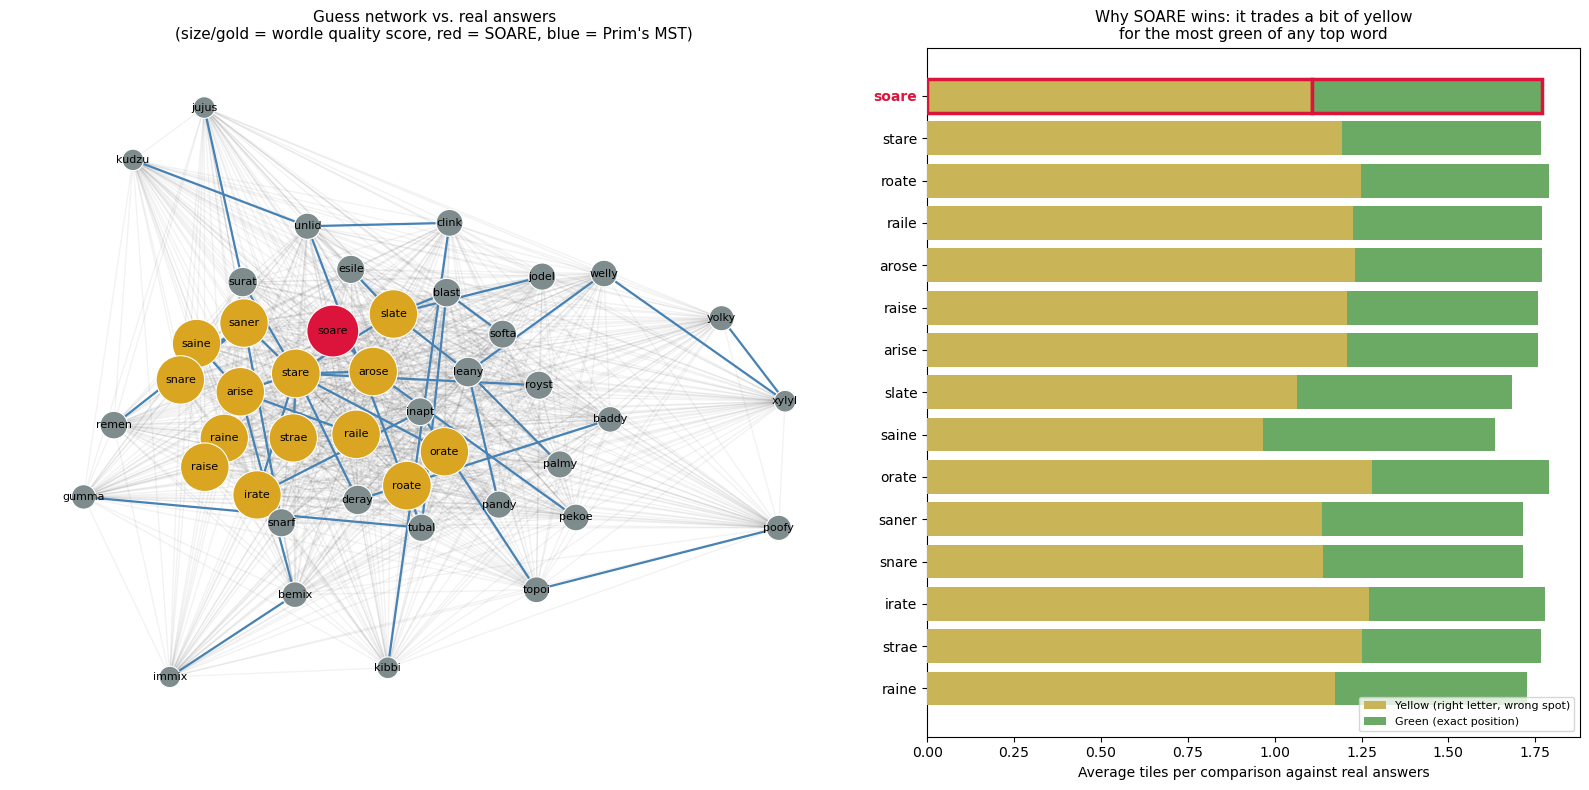

In [25]:
# Network Graph with color letter bar graph visual
WORDLE_GREEN = '#6aaa64'
WORDLE_YELLOW = '#c9b458'

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

# Panel 1: 
# network graph, sized/colored by quality score
ax1 = fig.add_subplot(gs[0])

top15 = combo_sorted.head(15)['word'].tolist()
bottom5 = combo_sorted.tail(5)['word'].tolist()
np.random.seed(42)
sample_words = list(np.random.choice(combo_sorted['word'], 25, replace=False))
node_words = sorted(set(top15 + bottom5 + sample_words))

G = nx.Graph()
G.add_nodes_from(node_words)
for i in range(len(node_words)):
    for j in range(i + 1, len(node_words)):
        d = word_distance(node_words[i], node_words[j])
        G.add_edge(node_words[i], node_words[j], distance=d, similarity=1 - d)
mst = nx.minimum_spanning_tree(G, weight='distance', algorithm='prim')

qmap = combo_sorted.set_index('word')['wordle_quality_score']
node_color, node_size = [], []
for w in G.nodes():
    if w == 'soare':
        node_color.append('crimson'); node_size.append(1400)
    elif w in top15:
        node_color.append('goldenrod'); node_size.append(300 + qmap[w] * 400)
    else:
        node_color.append('#7f8c8d'); node_size.append(150 + qmap[w] * 150)

pos = nx.spring_layout(G, weight='similarity', seed=7, k=0.6)
nx.draw_networkx_edges(G, pos, alpha=0.05, ax=ax1)
nx.draw_networkx_edges(mst, pos, edge_color='steelblue', width=1.6, ax=ax1)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, ax=ax1,
                        edgecolors='white', linewidths=0.8)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1)
ax1.set_title("Guess network vs. real answers\n(size/gold = wordle quality score, red = SOARE, blue = Prim's MST)", fontsize=11)
ax1.axis('off')

# Panel 2: 
# stacked bar showing the yellow/green breakdown
ax2 = fig.add_subplot(gs[1])
top = combo_sorted.head(15).iloc[::-1]  # reverse so #1 word lands at the top of the horizontal bar chart
y_pos = np.arange(len(top))

edge_colors = ['crimson' if w == 'soare' else 'none' for w in top['word']]
edge_widths = [2.5 if w == 'soare' else 0 for w in top['word']]

ax2.barh(y_pos, top['avg_yellow_matches'], color=WORDLE_YELLOW,
         label='Yellow (right letter, wrong spot)', edgecolor=edge_colors, linewidth=edge_widths, zorder=3)
ax2.barh(y_pos, top['avg_green_matches'], left=top['avg_yellow_matches'], color=WORDLE_GREEN,
         label='Green (exact position)', edgecolor=edge_colors, linewidth=edge_widths, zorder=3)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top['word'])
ax2.set_xlabel('Average tiles per comparison against real answers')
ax2.set_title('Why SOARE wins: it trades a bit of yellow\nfor the most green of any top word', fontsize=11)
ax2.legend(loc='lower right', fontsize=8)
for i, w in enumerate(top['word']):
    if w == 'soare':
        ax2.get_yticklabels()[i].set_color('crimson')
        ax2.get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

Based on the results above, the top *good* starting word is SOARE when considering both the letters and their position. 
If we don't want to take position into account, the words ROATE and ORATE (anagrams) are better; they beat SOARE on *raw letter overlap*  (avg_shared_letters ≈ 1.79 vs SOARE's 1.77).

To test these words, let's try SOARE on Wordle (9-2-2026)!

![Soare try on Wordle](images/2026-09-02.png)

And again (9-3-2026)!

![Soare try on Wordle](images/2026-09-03.png)


Frankly, the results are a bit disappointing. After all these calculations, I thought there would be more colored letters. It makes sense, but I still expected more from the word with the more ideal position accuracy. Even if we used ORATE or ROATE, the amount of colored letters would have been the same, only ROATE would have one green letter above the rest (for 09-02-2026).

What if we have more words to try it on?

Let's try SOARE with a [64 word Wordle](https://64ordle.au/)!
This is just Wordle but you are guessing for 64 words at the same time. I will show this below!

For the 64 Wordle you get 70 tries in total to guess all 64 words. 
As you can see below, each guess is applied to all 64 words.

![64 Word Wordle ZOOM](images/64Wordle.png)

*Note: this is for 9-2-2026*

![64 Word Wordle Day 2](images/64WordleDay2.png)

*Note: this is for 9-3-2026*

When looking at the second picture, the 64 Wordle shows us that each word is represented by a small grey sqaure within each letter. Using SOARE, we can see a lot of hits for E, O, and A (lots of yellow and green squares). It seems with a larger set of words, SOARE is a *good* starting word!

## So what does this mean?

In the end PENIS is not a *good* starting word. Ideally, you would use SOARE if you want to take both letters and letter position into consideration. If not, ORATE and ROATE are *good* starting words. 

It makes sense that all these words have the letter E in them since, as we saw in my 20 day and in Sean's wordle data, E is a very common vowel in five letter words. What I am personally surprised about is that the letters N and I are missing from these *good* words. Based on my initial hypothesis and my 20 day data, N and I seemed really common so I thought that even if PENIS was not a good starting word, that a good starting word would still include at least an I or N in it. I am also suprised to see that if we do not care for letter position accuracy, a good starting word includes the letter T. 

All this to say, next time you are trying to solve the word of the day on [Wordle](https://www.nytimes.com/games/wordle/index.html), try SOARE, ORATE, or ROATE!

**Bonus** A [post](https://www.reddit.com/r/wordle/comments/sif01i/how_did_roate_get_picked_as_the_tauted_best_first/) about how ROATE is the the superior starting word!